## Stepan-VORONYI-Camp-2026
# Hometask lesson 14: Data Engineering
# Phase 0: Preparation and Financial Safety

I successfully registered for an AWS Free Tier account using my email address and a Monobank virtual card with a small balance for verification. To fully secure the profile against hacking and protect against unexpected bills, multi-factor authentication (MFA) was enabled immediately, notification limits were configured via AWS Budgets, and the terms and quotas for free service usage were thoroughly analyzed before testing them.


To monitor financial expenses on AWS, a CloudWatch Billing Alarm was set up to trigger if the estimated invoice amount exceeds the $1 limit. To ensure prompt notification, email alerts were configured via the Amazon SNS service. The setup process was completed by successfully confirming the subscription by clicking the link in the verification email sent to the provided email address.

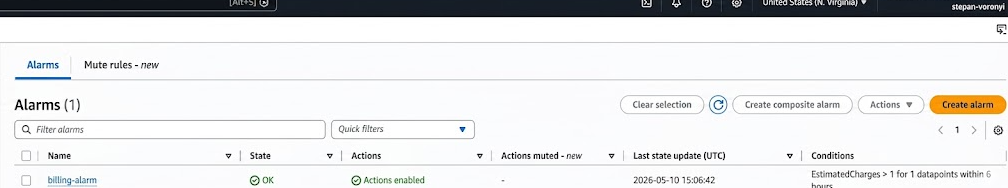
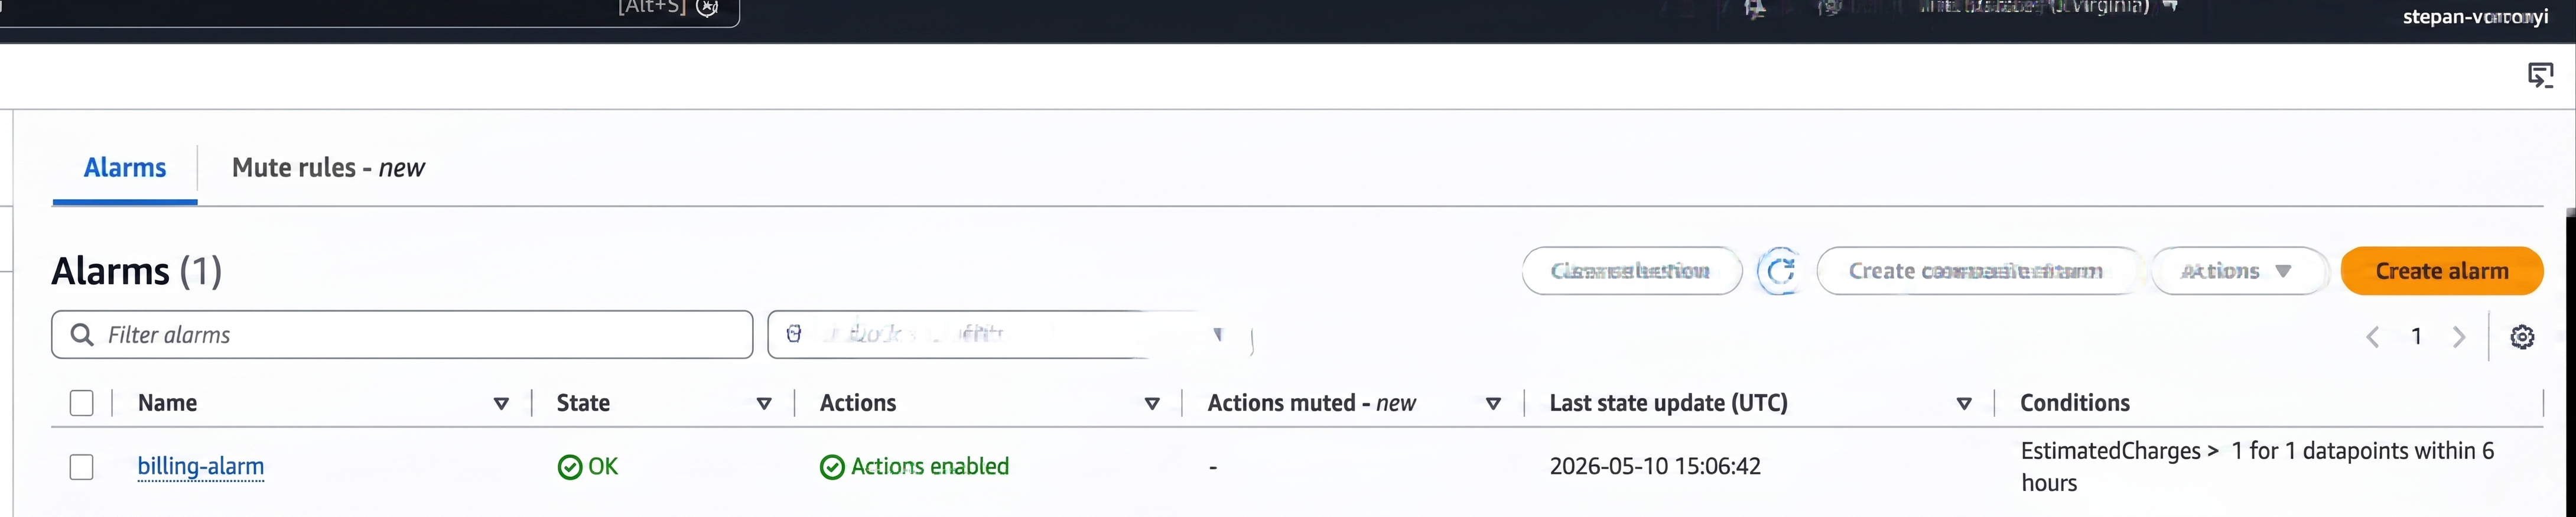

## Phase 1: Identity and Access Management (IAM)

During the first phase, basic security and identity and access management (IAM) measures were implemented. To avoid using the vulnerable root account in day-to-day operations, a separate user named data_engineer_stepan was created. 

This user was granted full administrative access via the AdministratorAccess policy and was given the ability to log in to the AWS Management Console. To maximize account security, two-factor authentication (MFA) was enabled, after which the first login was successfully performed to verify the settings.

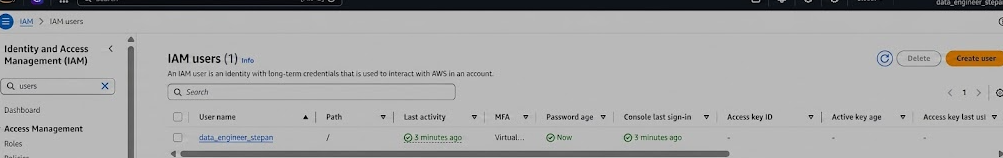
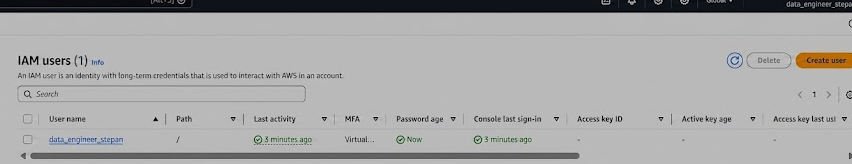

## Phase 2: Building a Data Lake with S3, Glue and Athena
## 2.1 S3: Data Storage

To ensure the secure storage of the initial datasets within the Data Lake pipeline deployment, a new Amazon S3 bucket named data-lake-stepan-2026 was created.

After the bucket was successfully created, an initial CSV file named customers.csv was uploaded to it.

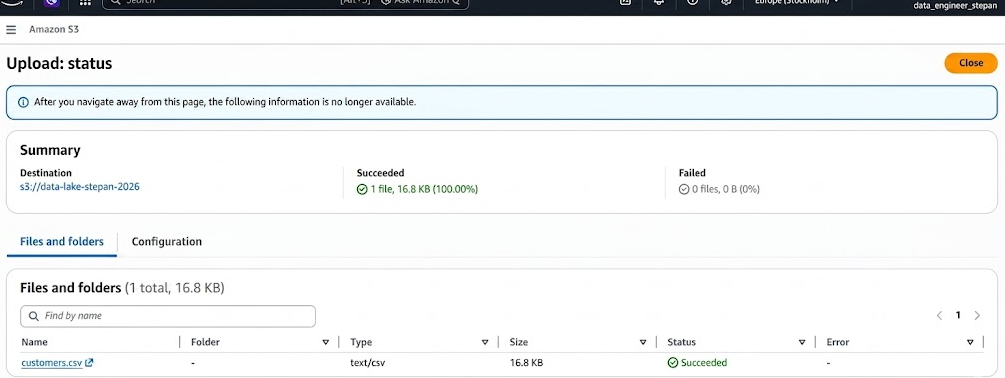

## 2.2 IAM Role: Access for AWS Glue

To ensure the proper functioning of the AWS Glue service, a dedicated IAM role named `glue-s3-role-stepan` was created.

This role allows Glue tools to securely read uploaded CSV files from an S3 bucket and register the resulting metadata in the Glue Data Catalog.

The following access policies are attached to the created role:

AmazonS3FullAccess — to grant full access to files in the S3 cloud storage.

AWSGlueServiceRole — to provide the Glue service with the technical capability to perform its internal system operations.

This role will subsequently be assigned to the Glue Crawler tool for automatically scanning the S3 bucket and dynamically designing table schemas.

## 2.3 AWS Glue Crawler: Automation

In the next step, an AWS Glue Crawler (named customers-data-crawler) was deployed, which scanned the contents of our S3 bucket using the permissions of the IAM role glue-s3-role-stepan. The crawler imported the automatically identified metadata into the customers_data_db database within the Glue Data Catalog. As a result, the service automatically recognized the schema of the customers.csv file and created the data_lake_stepan_2026 table with four distinct fields: the unique identifier customer_id (bigint), the email address email (string), the country code country (string), and the timestamp created_at (string).

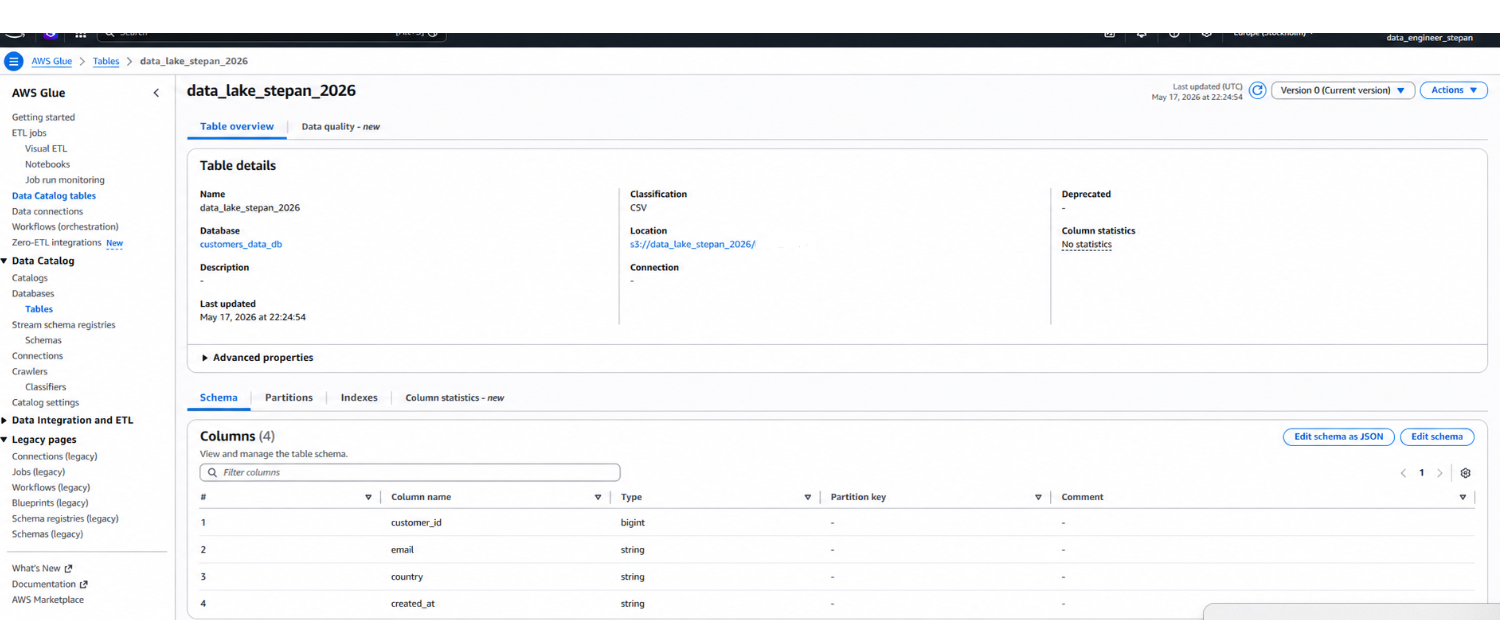

## 2.4 Amazon Athena: Querying Data

In the final stage, we used Amazon Athena’s interactive query tool to access the cleaned metadata directly. In the Query Editor, we selected the customers_data_db database and the data_lake_stepan_2026 table, which had been automatically generated by the AWS Glue Crawler. To ensure that all fields (customer_id, email, country, created_at) were displayed correctly and without errors, we ran a standard verification query: SELECT * FROM “customers_data_db”.“data_lake_stepan_2026” LIMIT 10;, which successfully returned the first 10 records from our Data Lake.

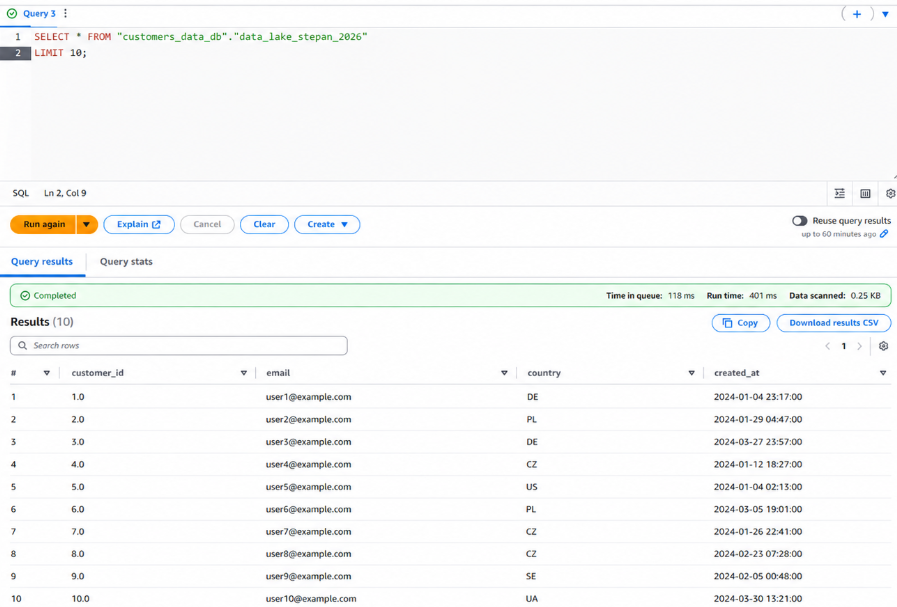